In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Pada tahap ini dilakukan impor berbagai library dan modul yang diperlukan untuk seluruh alur kerja pengolahan citra, ekstraksi fitur, klasifikasi, hingga evaluasi model. Library os digunakan untuk berinteraksi dengan sistem operasi, seperti mengakses dan mengelola struktur folder dataset. OpenCV (cv2) berfungsi untuk membaca, memanipulasi, dan memproses citra digital. NumPy (np) digunakan untuk menangani komputasi numerik dan operasi array multidimensi, sedangkan Matplotlib (plt) digunakan untuk menampilkan citra maupun grafik hasil analisis. Pandas (pd) digunakan untuk menyimpan dan mengorganisasi data hasil ekstraksi fitur ke dalam bentuk tabel (DataFrame). Untuk kebutuhan machine learning, library scikit-learn (sklearn) menyediakan modul train_test_split dan cross_val_predict untuk pembagian data serta validasi silang. Algoritma klasifikasi yang digunakan meliputi RandomForestClassifier, SVC (Support Vector Classifier), dan KNeighborsClassifier. Guna mengekstrak fitur tekstur dari citra, digunakan fungsi graycomatrix dan graycoprops dari skimage.feature untuk perhitungan matriks GLCM, didukung oleh scipy.stats untuk menghitung nilai entropi. Terakhir, evaluasi performa model dilakukan menggunakan berbagai metrik seperti akurasi, presisi, recall, f1-score, serta confusion_matrix yang divisualisasikan secara estetis menggunakan ConfusionMatrixDisplay dan library seaborn (sns).

In [2]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 500
Kelas: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


Pada tahap ini, dilakukan inisialisasi list kosong (data, labels, file_name) serta penentuan dimensi standar IMG_SIZE sebesar 128 x 128 piksel sebagai persiapan pemrosesan data. Menggunakan perulangan bertingkat (nested loop) dengan fungsi os.listdir dan os.path.join, program otomatis menelusuri setiap sub-folder di dalam direktori "dataset" untuk membaca file citra menggunakan OpenCV (cv.imread). Terdapat proses validasi (if img is None) untuk melewati file yang rusak, sedangkan citra yang valid akan disimpan ke dalam list bersama dengan nama sub-folder sebagai label kelas dan format penamaan baru yang terstruktur.

# Data Preparation
### Define Preprocessing Function

In [3]:
TARGET_SIZE = (128, 128)

def re_gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def median(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input)
    else:
        img = image_input.copy()

    median_hasil = cv.medianBlur(img, kernel_size)
    return median_hasil

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img,pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i,j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx) #konvolusi sumbu x
    gy = convolution(img, kernely) #konvolusi sumbu y
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas) #normalisasi ke 0-255
    return np.clip(canvas, 0, 255).astype(np.uint8)  # batas nilai dan konversi

#kernel sobel sumbu x
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

#kernel sobel sumbu y
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

#kernel roberts sumbu x
robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

#kernel sobel sumbu y
robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

# Tahap Pra-pemrosesan Citra (Percobaan 3)

## 1. Pra-pemrosesan Awal (Fungsi dari Percobaan 2)
Blok kode ini mendefinisikan tiga fungsi modular untuk tahap pra-pemrosesan citra digital menggunakan OpenCV dan NumPy. Fungsi pertama, `re_gray`, bertugas mengubah ukuran dimensi gambar menjadi 128 kali 128 piksel dan mengonversinya ke format *grayscale* menggunakan `cv.cvtColor` jika inputnya terdeteksi sebagai citra berwarna. Fungsi kedua, `median`, berfungsi untuk mereduksi *noise* atau bintik pada gambar dengan menerapkan filter penyaringan *median blur* lewat `cv.medianBlur` menggunakan ukuran kernel default 5. Fungsi ketiga, `histogram_equalization`, digunakan untuk meratakan dan meningkatkan kualitas kontras citra secara otomatis melalui fungsi `cv.equalizeHist`.

## 2. Pra-pemrosesan Lanjutan: Operasi Konvolusi Manual
Blok kode ini mendefinisikan fungsi `convolution` untuk melakukan operasi matematika konvolusi dua dimensi secara manual pada citra sebagai bagian dari pra-pemrosesan lanjutan. Fungsi ini bekerja dengan mengaplikasikan sebuah matriks kernel ke seluruh bagian citra menggunakan perulangan *loop*. Sebelum pemindaian konvolusi dilakukan, fungsi ini menambahkan bantalan nol (*zero padding*) di sekeliling tepi citra asli menggunakan `np.pad` dengan mode *constant*, sehingga dimensi citra keluaran yang dihasilkan pada kanvas baru akan tetap konsisten dan sama persis dengan dimensi citra masukan.

## 3. Pra-pemrosesan Lanjutan: Deteksi Tepi (Edge Detection)
Blok kode selanjutnya mendefinisikan fungsi `edge` yang berperan utama dalam proses pra-pemrosesan ekstraksi fitur deteksi tepi objek pada citra digital. Fungsi ini memanfaatkan fungsi konvolusi sebelumnya untuk menghitung nilai magnitudo gradien pada sumbu X dan sumbu Y menggunakan kernel spesifik yang diinputkan. Setelah mendapatkan nilai mutlak dari kedua gradien menggunakan `np.abs`, hasilnya digabungkan dan dinormalisasi secara proporsional ke dalam rentang nilai 0 hingga 255. Tahap akhir melibatkan fungsi `np.clip` untuk memastikan tidak ada intensitas piksel yang melewati batas nilai tersebut sebelum dikonversi secara final menjadi tipe data *unsigned integer* 8-bit (`np.uint8`).

## 4. Komponen Pra-pemrosesan: Definisi Kernel Operator
Blok kode terakhir ini mendefinisikan komponen pra-pemrosesan berupa matriks kernel dari dua operator deteksi tepi yang sangat umum digunakan, yaitu Sobel dan Roberts, menggunakan bentuk *array* dari NumPy dengan tipe data `float32`. Operator Sobel direpresentasikan dengan matriks berukuran 3x3 (`sobelX` dan `sobelY`) yang dirancang untuk mendeteksi perubahan intensitas secara horizontal dan vertikal sekaligus memberikan sedikit efek penghalusan (*smoothing*) untuk meminimalisir *noise*. Sementara itu, operator Roberts Cross direpresentasikan dengan matriks 2x2 (`robertsX` dan `robertsY`) yang difokuskan untuk menghitung perkiraan gradien secara diagonal parsial dengan metode komputasi yang jauh lebih ringan dan cepat.

In [4]:
def prepro(image):
    img = re_gray(image)
    img = median(img)
    sobel = edge(img, sobelX, sobelY)
    roberts = edge(sobel, robertsX, robertsY)

    return roberts

## Alur Utama Pra-pemrosesan Citra (Fungsi prepro)
Blok kode ini mendefinisikan fungsi utama `prepro` yang merangkai seluruh komponen pra-pemrosesan sebelumnya menjadi satu alur eksekusi (*pipeline*) yang terstruktur. Fungsi ini menerima citra mentah sebagai masukan, lalu secara berurutan memanggil fungsi `re_gray` untuk standardisasi ukuran dan konversi *grayscale*, dilanjutkan dengan fungsi `median` untuk reduksi *noise*, dan `histogram_equalization` untuk penyesuaian kontras citra. Setelah tahapan perbaikan kualitas citra dasar selesai, fungsi ini melakukan ekstraksi fitur secara bertingkat; pertama dengan menerapkan deteksi tepi menggunakan operator Sobel, kemudian hasil deteksi tepi Sobel tersebut diproses lebih lanjut menggunakan operator Roberts Cross. Citra hasil komputasi dari filter Roberts inilah yang pada akhirnya dikembalikan sebagai *output* final dari keseluruhan proses pra-pemrosesan.

## Implementasi dan Visualisasi Hasil (Percobaan 3)
Blok kode ini berfungsi untuk menerapkan seluruh tahapan pra-pemrosesan ke dalam kumpulan data citra dan memvisualisasikan hasilnya. Pertama, didefinisikan sebuah fungsi *wrapper* bernama `percobaan3` yang akan memanggil alur `prepro` sebelumnya. Fungsi ini kemudian diaplikasikan secara massal pada seluruh citra mentah di dalam dataset menggunakan metode *list comprehension*, dan citra yang sudah terproses disimpan ke dalam variabel *list* baru.

Selanjutnya, kode melakukan ekstraksi label-label atau kategori unik dari dataset yang ada dan mengurutkannya. Melalui perulangan *loop* untuk setiap label kategori yang unik, program mencari indeks citra mana saja yang bersesuaian dengan label tersebut. Sistem kemudian memanfaatkan *library* Matplotlib untuk membuat sebuah kanvas *figure* berupa *grid* (tata letak) berukuran 4 baris dan 6 kolom, yang dirancang untuk menampilkan maksimal 24 citra sampel secara bersamaan untuk setiap kategorinya.

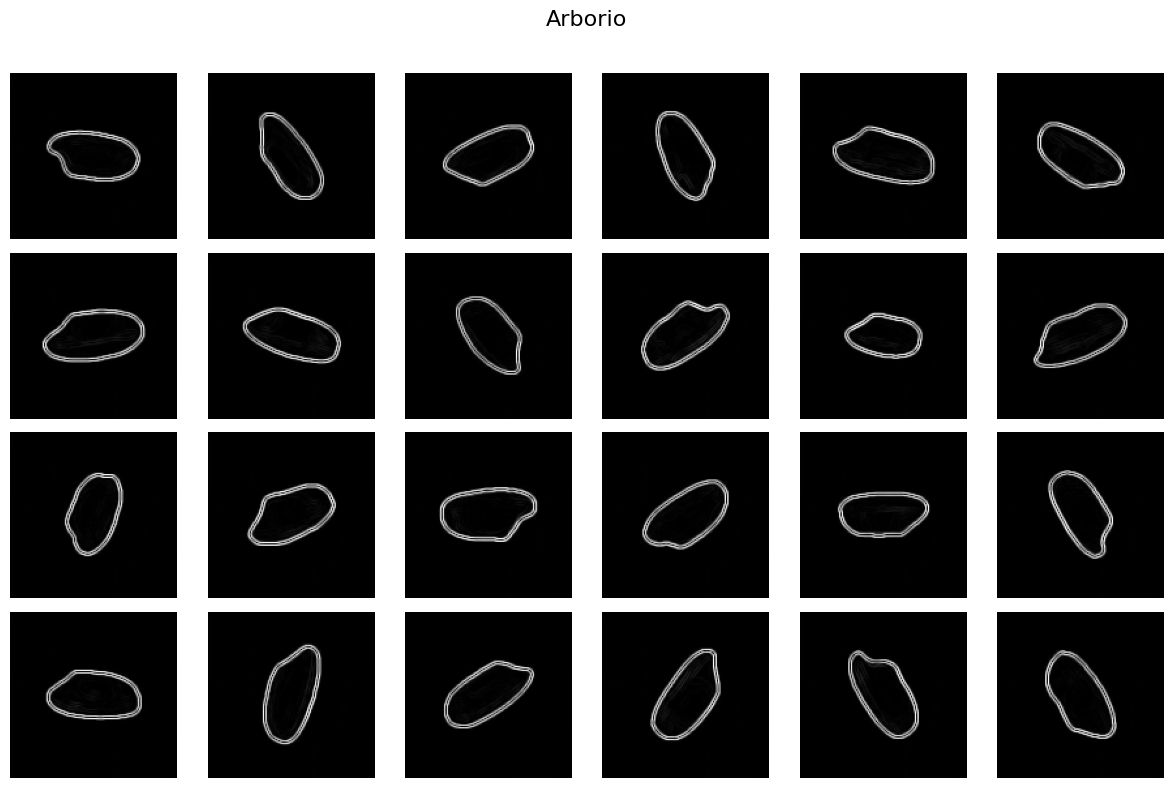

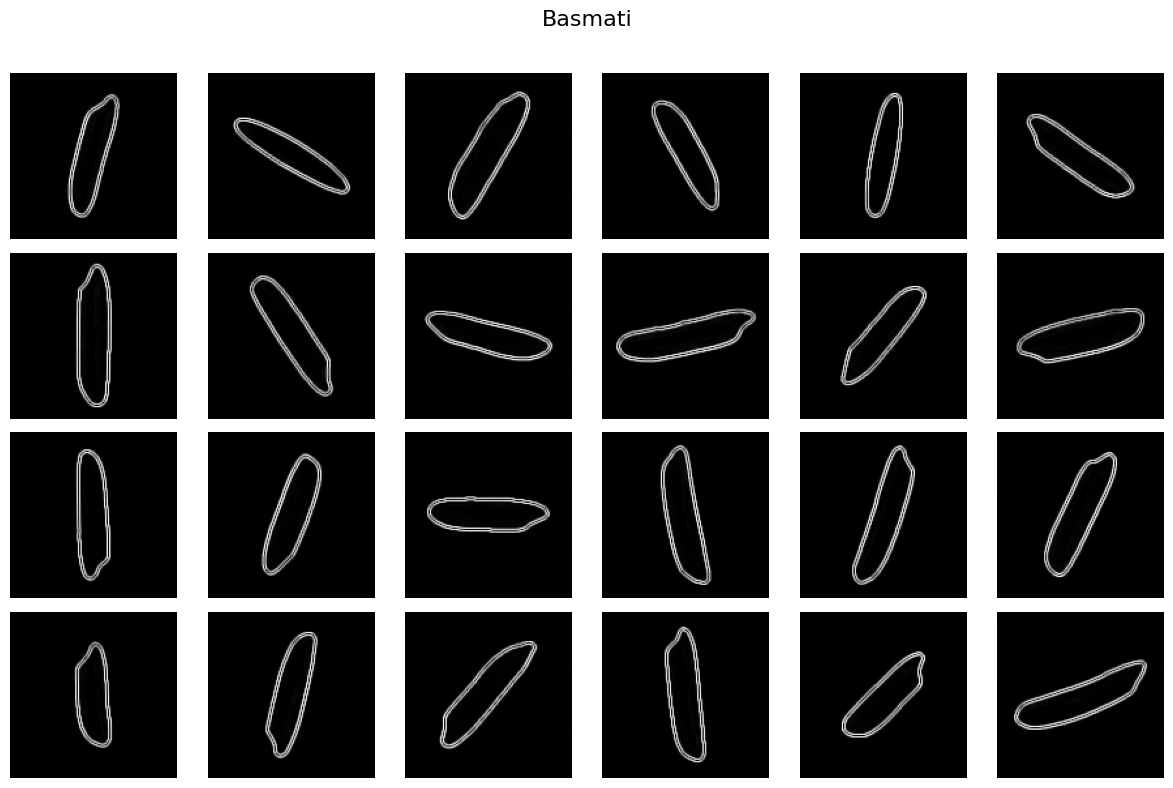

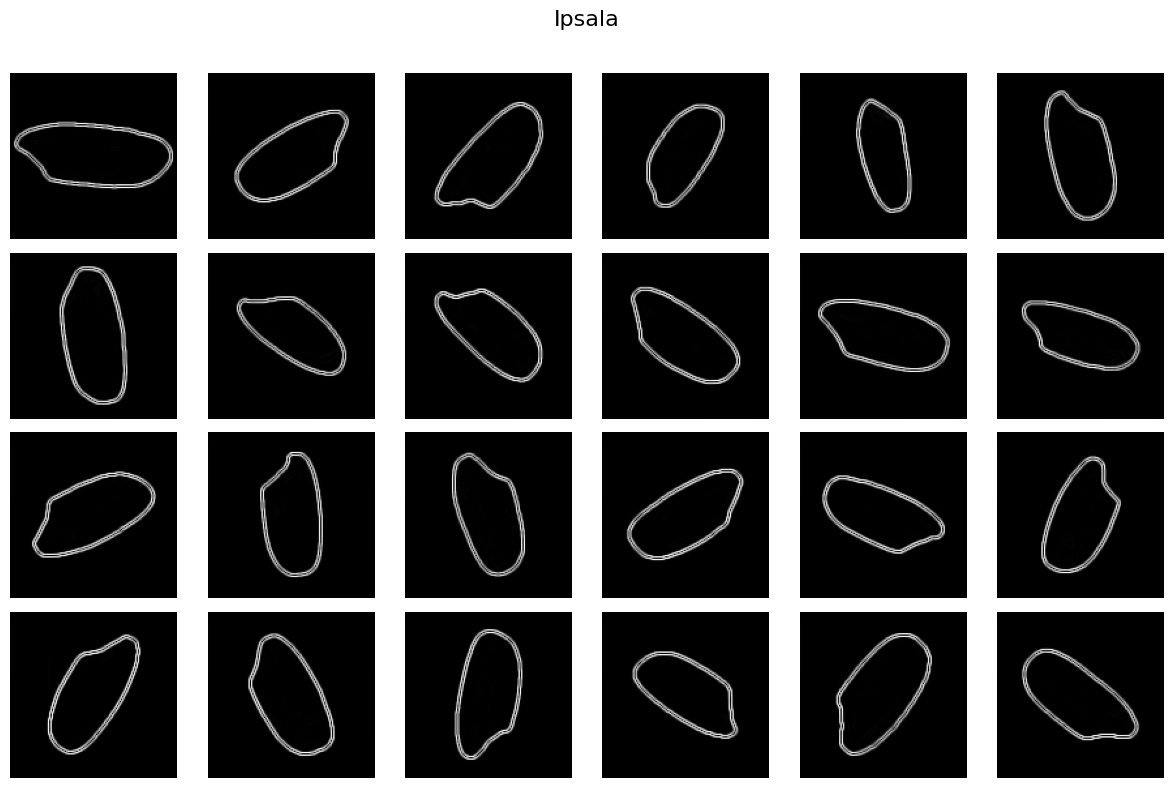

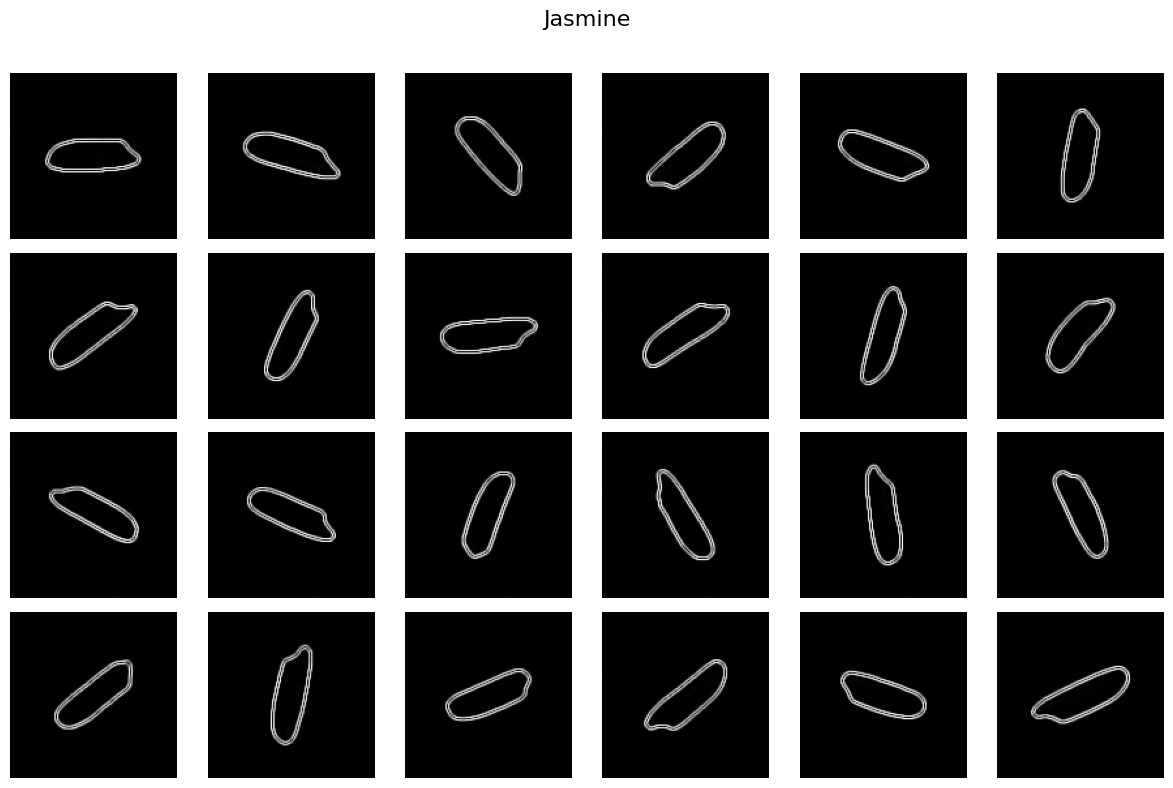

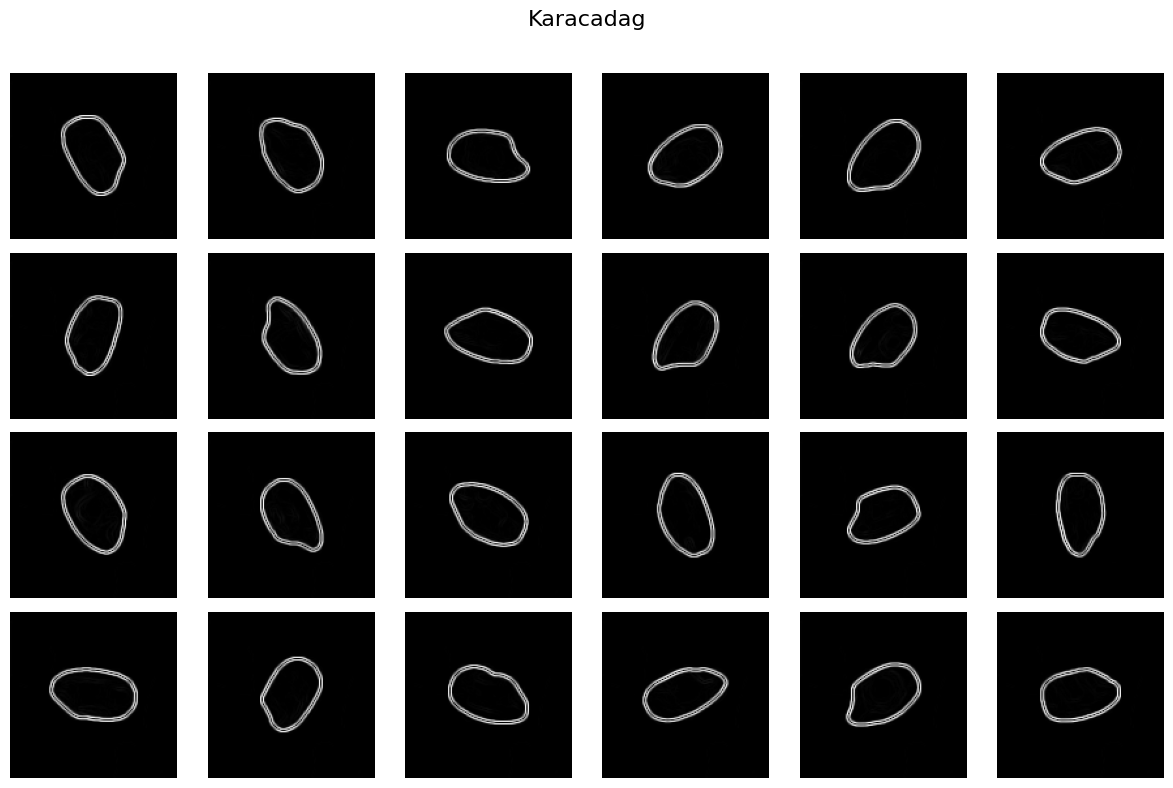

In [5]:
def percobaan3(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan3(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(24, len(idxs))):
        row = k // 6
        col = k % 6
        ax  = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [6]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

## Ekstraksi Fitur Tekstur dengan GLCM
Blok kode ini mendefinisikan fungsi `glcm` untuk mengekstraksi fitur tekstur citra menggunakan metode *Gray-Level Co-occurrence Matrix* (GLCM). Fungsi menerima masukan citra dan sudut komputasi (0, 45, 90, atau 135 derajat) yang akan dikonversi menjadi satuan radian. Jika input sudut tidak sesuai, fungsi akan menampilkan pesan *ValueError*. 

Setelah sudut divalidasi, fungsi membentuk matriks kookurensi melalui `graycomatrix` dengan pengaturan jarak antarpiksel sebesar 1 dan cakupan 256 tingkat keabuan. Parameter `symmetric` dan `normed` diaktifkan agar matriks yang dihasilkan bersifat simetris dan dinormalisasi menjadi nilai probabilitas, yang kemudian dikembalikan sebagai *output* akhir.

In [7]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Ekstraksi Fitur Statistik GLCM
Blok kode ini mendefinisikan serangkaian fungsi singkat untuk menghitung berbagai metrik fitur tekstur dari matriks GLCM yang telah dibuat sebelumnya. Enam fitur statistik utama—yaitu korelasi, disimilaritas, homogenitas, kontras, ASM (*Angular Second Moment*), dan energi—diekstraksi secara langsung dengan memanggil fungsi bawaan `graycoprops`. 

Sementara itu, fungsi terakhir (`entropyGlcm`) secara khusus digunakan untuk menghitung nilai entropi. Pada fungsi ini, dimensi matriks GLCM diratakan terlebih dahulu menjadi susunan satu dimensi (*flatten*) menggunakan metode `ravel()` sebelum diproses lebih lanjut untuk mendapatkan nilai entropinya.

In [8]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")
     

Ekstraksi fitur selesai untuk 500 citra.


## Penerapan Ekstraksi Fitur secara Massal
Blok kode ini mengeksekusi proses komputasi GLCM dan ekstraksi fitur secara menyeluruh pada semua dataset citra yang telah dipra-pemrosesan. Proses ini dilakukan dalam dua tahapan iterasi (perulangan) utama. Pada tahap pertama, program menghitung dan menyimpan matriks GLCM dari masing-masing citra untuk empat arah sudut komputasi (0, 45, 90, dan 135 derajat) ke dalam *list* (daftar) penampung yang terpisah. 

Setelah matriks GLCM berhasil dibentuk, tahap kedua dijalankan untuk mengekstraksi tujuh nilai fitur statistik (kontras, disimilaritas, homogenitas, entropi, ASM, energi, dan korelasi) dari masing-masing matriks tersebut. Seluruh hasil ekstraksi kemudian dikelompokkan dan disimpan ke dalam puluhan variabel *list* spesifik berdasarkan jenis fitur dan arah sudutnya, yang nantinya siap digunakan sebagai dataset untuk tahap analisis atau pelatihan model pengenalan pola.

## Penyusunan Dataset dan Penyimpanan ke CSV
Blok kode ini berfungsi untuk menyatukan seluruh data hasil ekstraksi fitur ke dalam bentuk tabel struktural menggunakan pustaka Pandas. Seluruh variabel *list* yang berisi nilai fitur statistik, beserta informasi nama *file* dan label kategorinya, dikumpulkan terlebih dahulu ke dalam sebuah *dictionary*. Objek ini kemudian dikonversi menjadi *DataFrame* agar mudah diolah. 

Setelah tabel terbentuk, data tersebut diekspor dan disimpan secara permanen ke dalam sebuah *file* berformat CSV. Pada baris terakhir, program memuat dan membaca kembali *file* CSV yang baru saja dibuat untuk memverifikasi serta menampilkan isi *dataset* akhir secara langsung ke layar.

In [9]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('./hasil_ekstraksi/hasil_ekstraksi3.csv', index=False)

hasilEkstrak = pd.read_csv('./hasil_ekstraksi/hasil_ekstraksi3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Arborio_1.jpg,Arborio,261.347995,818.771344,812.037032,897.737429,0.879600,0.861021,0.868284,0.857519,...,0.647604,0.637846,0.805452,0.801430,0.804738,0.798653,0.850045,0.533739,0.534061,0.488771
1,Arborio_2.jpg,Arborio,599.760458,592.424639,398.574742,869.996342,0.867851,0.872253,0.879058,0.856428,...,0.664920,0.647646,0.810232,0.810380,0.815426,0.804765,0.623439,0.630836,0.749748,0.457869
2,Arborio_3.jpg,Arborio,365.809855,661.265609,516.496309,502.064914,0.865682,0.853120,0.865468,0.859871,...,0.637395,0.629200,0.796614,0.792829,0.798371,0.793222,0.772814,0.592395,0.679222,0.690527
3,Arborio_4.jpg,Arborio,671.538693,583.733337,352.877830,821.706925,0.862492,0.864712,0.879634,0.856145,...,0.656761,0.639097,0.802606,0.802840,0.810408,0.799435,0.626375,0.677664,0.803664,0.546255
4,Arborio_5.jpg,Arborio,351.749938,817.203112,837.799336,1003.957778,0.852227,0.833143,0.836846,0.827855,...,0.598656,0.592590,0.777567,0.772543,0.773728,0.769798,0.819782,0.584431,0.570745,0.489462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Karacadag_96.jpg,Karacadag,305.035987,485.621613,566.640133,726.035402,0.876941,0.870057,0.874244,0.862667,...,0.656556,0.647410,0.809931,0.808055,0.810281,0.804618,0.807695,0.696147,0.642761,0.545721
496,Karacadag_97.jpg,Karacadag,527.455647,731.500961,372.663263,505.188108,0.880708,0.872582,0.889342,0.874998,...,0.672463,0.661363,0.815062,0.813217,0.820039,0.813242,0.683381,0.564207,0.776294,0.699033
497,Karacadag_98.jpg,Karacadag,352.605007,670.162502,427.826772,456.313163,0.876303,0.863852,0.881119,0.870074,...,0.662038,0.652205,0.809367,0.805686,0.813657,0.807592,0.756285,0.540274,0.704285,0.686973
498,Karacadag_99.jpg,Karacadag,449.613989,458.739103,392.568282,668.203918,0.882224,0.880697,0.888370,0.871748,...,0.671445,0.659646,0.816513,0.815321,0.819418,0.812186,0.700987,0.697220,0.738919,0.558968


## Seleksi Fitur dan Visualisasi Korelasi
Blok kode ini berfokus pada tahap reduksi dimensi dengan melakukan seleksi fitur berbasis korelasi untuk membuang data yang redundan. Pertama, program menghitung matriks korelasi antar seluruh fitur numerik dengan mengabaikan kolom label dan nama *file*. Selanjutnya, ditetapkan sebuah nilai ambang batas (*threshold*) sebesar 0,95. Melalui proses iterasi, program mengevaluasi nilai korelasi absolut antar pasangan fitur; jika korelasinya menyentuh atau melebihi 0,95, salah satu fitur dari pasangan tersebut akan dieliminasi karena dianggap memberikan informasi yang tumpang tindih.

Setelah fitur-fitur yang redundan berhasil disaring, fitur-fitur independen yang tersisa diekstrak ke dalam variabel baru sebagai data masukan akhir. Program kemudian mencetak ringkasan informasi mengenai jumlah fitur sebelum dan sesudah seleksi beserta nama-nama fitur yang berhasil dipertahankan. Terakhir, kumpulan fitur terpilih tersebut divisualisasikan kembali menggunakan peta panas (*heatmap*) korelasi dari pustaka Seaborn untuk melihat persebaran interaksi antardata yang baru.

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 13
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Homogeneity135', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


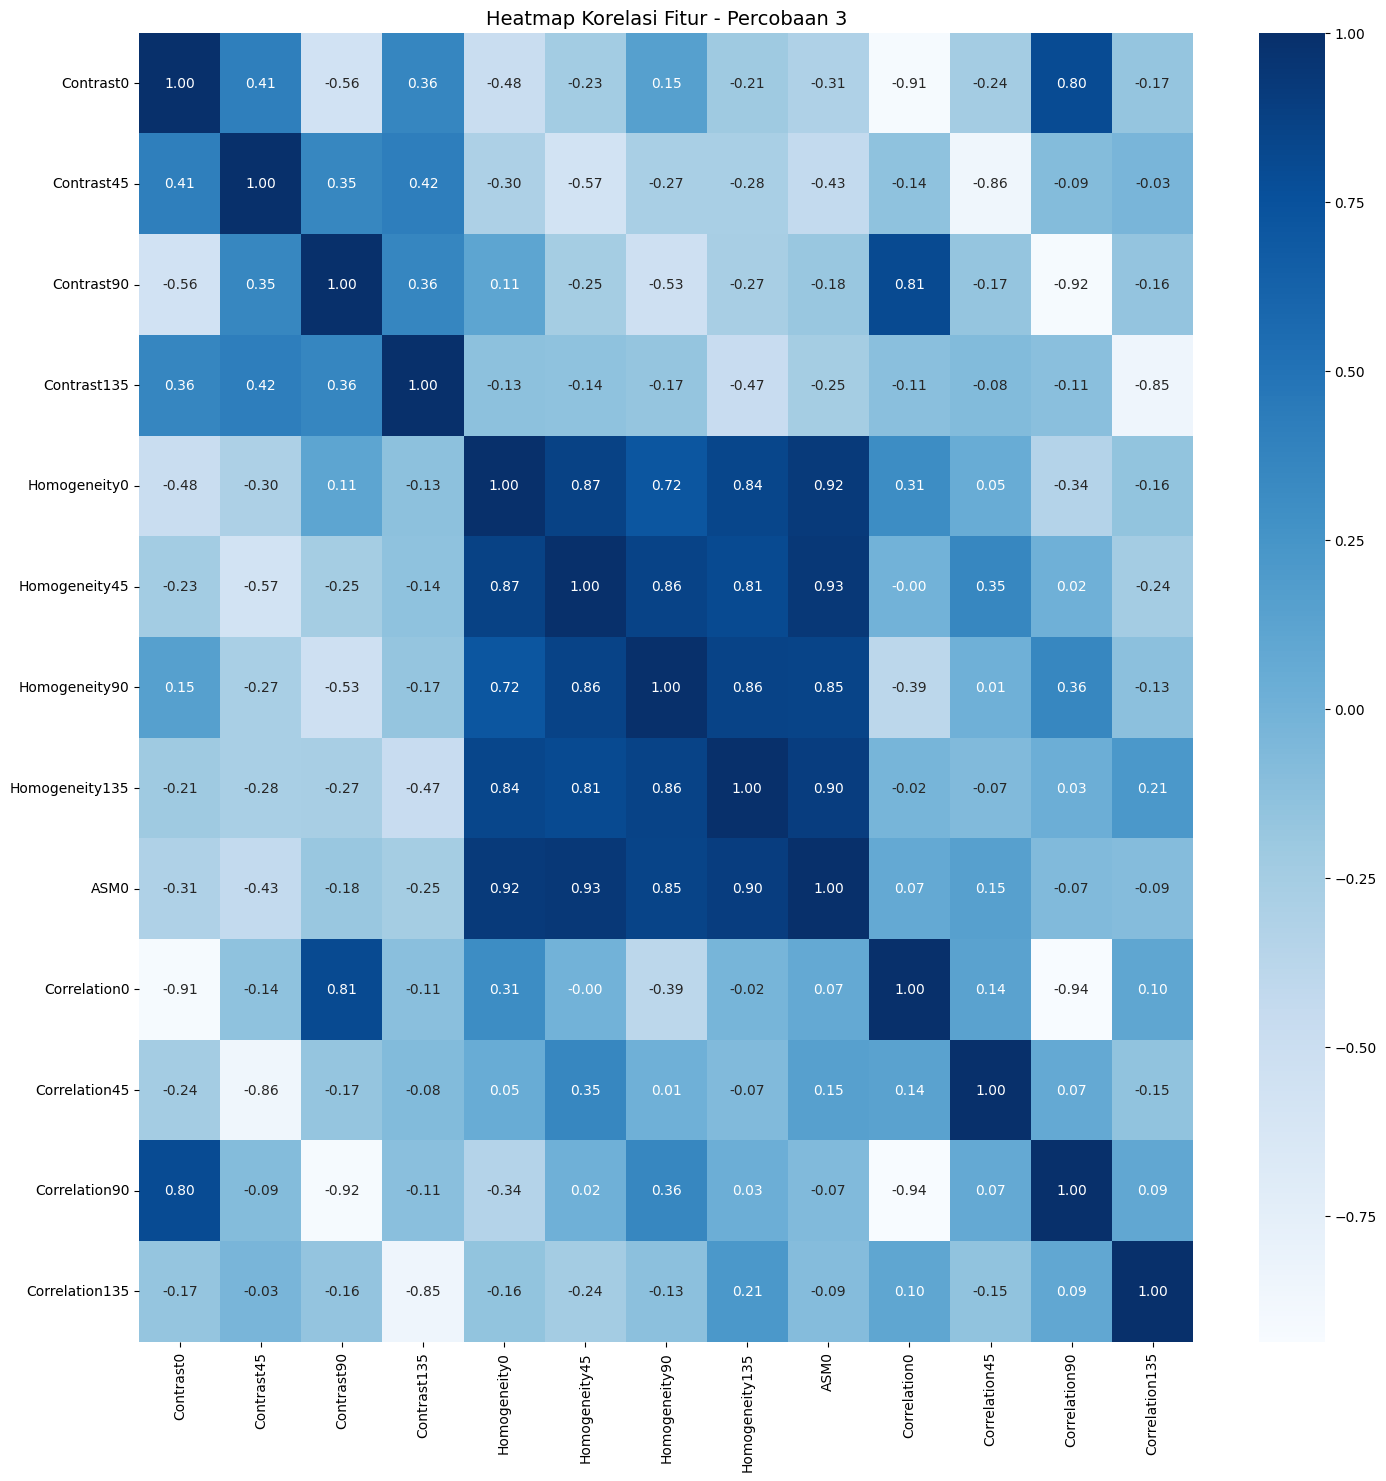

In [10]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 3', fontsize=14)
plt.show()

## Pemisahan Data Latih dan Data Uji
Blok kode ini bertujuan untuk membagi dataset fitur dan label menjadi dua himpunan terpisah: data latih (*training set*) dan data uji (*testing set*). Dengan menggunakan fungsi `train_test_split`, proporsi pembagian diatur sebesar 80% untuk pelatihan dan 20% untuk pengujian melalui parameter `test_size=0.2`. Penggunaan parameter `random_state=42` berfungsi sebagai kontrol pengacakan (*seed*) agar proses pemisahan data bersifat konsisten dan dapat direproduksi jika program dijalankan ulang. Sebagai langkah validasi akhir, fungsi akan mencetak dimensi ukuran dari data latih dan data uji untuk memastikan proses pembagian baris data telah dilakukan dengan benar.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(400, 13)
(100, 13)


## Standardisasi Data (Z-Score Normalization)
Blok kode ini melakukan tahap standardisasi data agar rentang nilai pada setiap fitur menjadi seragam dan seimbang. Proses dimulai dengan menghitung nilai rata-rata (*mean*) dan simpangan baku (*standard deviation*) secara eksklusif hanya dari data latih. Kedua nilai statistik tersebut kemudian diaplikasikan dengan rumus *Z-score* untuk menskalakan ulang baik data latih maupun data uji. Pendekatan ini—di mana parameter perhitungan dari data latih digunakan untuk menormalisasi data uji—merupakan praktik penting guna mencegah terjadinya kebocoran informasi (*data leakage*) sehingga proses pengujian model tetap objektif dan valid.

In [12]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

## Evaluasi dan Inisialisasi Model Klasifikasi
Blok kode ini mendefinisikan sebuah fungsi pembantu bernama `generateClassificationReport` yang bertugas untuk merangkum dan menampilkan hasil evaluasi kinerja model secara komprehensif. Fungsi ini memproses label data asli dan label hasil prediksi untuk mencetak tiga metrik evaluasi utama, yaitu laporan klasifikasi (yang mencakup nilai presisi, *recall*, dan *F1-score*), matriks kebingungan (*confusion matrix*) untuk memetakan distribusi detail tebakan model yang benar dan salah, serta skor akurasi secara keseluruhan.

Selain fungsi evaluasi, blok kode ini juga melakukan tahap inisialisasi untuk tiga algoritma *machine learning* yang akan diuji sebagai model pengklasifikasi. Ketiga model tersebut meliputi *Random Forest* yang dikonfigurasi menggunakan 5 pohon keputusan, *Support Vector Machine* (SVM) dengan *kernel Radial Basis Function* (RBF), dan *K-Nearest Neighbors* (KNN) yang diatur untuk mengevaluasi 5 tetangga terdekat. Penggunaan parameter `random_state` pada algoritma *Random Forest* dan SVM ditambahkan untuk mengunci pengacakan internal, sehingga metrik kinerja yang dihasilkan oleh model akan tetap konsisten dan dapat direproduksi pada setiap pengujian.

In [13]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Pelatihan dan Evaluasi Model Random Forest
Blok kode ini berfokus pada tahap pelatihan dan pengujian kinerja model pengklasifikasi *Random Forest*. Proses dimulai dengan menyuapkan data fitur beserta label dari data latih agar model dapat mempelajari pola menggunakan metode `fit`. Setelah proses pembelajaran selesai, program mengeksekusi prediksi dan mencetak metrik evaluasi ke dalam dua tahapan terpisah. 

Tahap pengujian pertama dilakukan kembali pada data latih itu sendiri untuk mengevaluasi seberapa baik model menghafal dan mengenali pola awal (sering digunakan untuk mendeteksi indikasi *overfitting*). Selanjutnya, tahap pengujian kedua dilakukan secara objektif menggunakan data uji yang belum pernah dikenali oleh model sebelumnya guna mengukur kemampuan generalisasi atau performa aslinya di dunia nyata. Hasil prediksi dari masing-masing himpunan data tersebut langsung diproses dan ditampilkan menggunakan fungsi `generateClassificationReport` yang telah dibuat sebelumnya.

In [14]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     Arborio       1.00      0.97      0.99        72
     Basmati       0.97      0.99      0.98        86
      Ipsala       0.98      0.99      0.98        90
     Jasmine       0.97      0.99      0.98        76
   Karacadag       1.00      0.97      0.99        76

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400

[[70  1  1  0  0]
 [ 0 85  1  0  0]
 [ 0  1 89  0  0]
 [ 0  1  0 75  0]
 [ 0  0  0  2 74]]
Accuracy: 0.9825

------Testing Set------
              precision    recall  f1-score   support

     Arborio       0.77      0.82      0.79        28
     Basmati       0.87      0.93      0.90        14
      Ipsala       0.82      0.90      0.86        10
     Jasmine       0.95      0.75      0.84        24
   Karacadag       0.76      0.79      0.78        24

    accuracy               

## Pelatihan dan Evaluasi Model SVM
Blok kode ini memiliki struktur alur yang identik dengan proses sebelumnya, namun kali ini difokuskan pada pengujian algoritma *Support Vector Machine* (SVM). Proses dimulai dengan melatih model SVM menggunakan himpunan data latih melalui metode `fit`. Setelah model selesai mempelajari pola, program melakukan tahap prediksi dan mencetak hasil evaluasinya secara berurutan; pertama mengevaluasi kembali data latih untuk meninjau kecocokan model, kemudian dilanjutkan dengan mengevaluasi data uji secara objektif untuk mengukur seberapa baik kemampuan generalisasi model terhadap data baru. Hasil metrik kinerja dari kedua pengujian tersebut direkapitulasi secara otomatis dengan memanggil fungsi `generateClassificationReport`.

In [15]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Arborio       0.94      0.88      0.91        72
     Basmati       0.99      0.99      0.99        86
      Ipsala       1.00      0.97      0.98        90
     Jasmine       0.96      1.00      0.98        76
   Karacadag       0.90      0.96      0.93        76

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400

[[63  0  0  1  8]
 [ 0 85  0  1  0]
 [ 2  1 87  0  0]
 [ 0  0  0 76  0]
 [ 2  0  0  1 73]]
Accuracy: 0.96

------Testing Set------
              precision    recall  f1-score   support

     Arborio       0.96      0.82      0.88        28
     Basmati       0.88      1.00      0.93        14
      Ipsala       0.90      0.90      0.90        10
     Jasmine       1.00      0.96      0.98        24
   Karacadag       0.85      0.96      0.90        24

    accuracy                

## Pelatihan dan Evaluasi Model KNN
Blok kode ini menerapkan alur pelatihan dan pengujian yang selaras dengan dua model sebelumnya, namun kali ini diaplikasikan pada algoritma *K-Nearest Neighbors* (KNN). Proses diawali dengan membiarkan model KNN mempelajari distribusi pola dari himpunan data latih melalui metode `fit`. 

Setelah tahap pembelajaran selesai, program melakukan prediksi dan evaluasi kinerja dalam dua tahap terpisah. Tahap pertama mengevaluasi hasil prediksi pada data latih untuk meninjau kecocokan pola awal, yang kemudian dilanjutkan dengan tahap pengujian objektif menggunakan data uji guna mengukur seberapa akurat model mengenali data baru. Semua rekapitulasi metrik performa untuk kedua pengujian tersebut langsung diproses dan ditampilkan menggunakan fungsi `generateClassificationReport`.

In [16]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Arborio       0.88      0.85      0.87        72
     Basmati       1.00      0.90      0.94        86
      Ipsala       0.93      0.94      0.94        90
     Jasmine       0.96      1.00      0.98        76
   Karacadag       0.87      0.96      0.91        76

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

[[61  0  0  1 10]
 [ 2 77  6  1  0]
 [ 4  0 85  0  1]
 [ 0  0  0 76  0]
 [ 2  0  0  1 73]]
Accuracy: 0.93

------Testing Set------
              precision    recall  f1-score   support

     Arborio       0.84      0.93      0.88        28
     Basmati       1.00      1.00      1.00        14
      Ipsala       0.89      0.80      0.84        10
     Jasmine       1.00      0.96      0.98        24
   Karacadag       0.91      0.88      0.89        24

    accuracy                

## Visualisasi Matriks (Confusion Matrix)
Blok kode ini mendefinisikan fungsi pembantu `plot_confusion_matrix` untuk menampilkan matriks kebingungan secara grafis. Fungsi ini bekerja dengan mengonversi matriks kebingungan numerik menjadi format antarmuka visual menggunakan modul `ConfusionMatrixDisplay` dan menerapkan skema warna gradasi biru agar tingkat konsentrasi distribusi prediksi (baik yang benar maupun keliru) menjadi lebih intuitif untuk dianalisis secara visual. Setelah fungsi pendukung ini siap, program memanggilnya secara berurutan untuk mencetak grafik evaluasi kinerja dari himpunan data uji pada ketiga pengklasifikasi yang telah dilatih—yaitu Random Forest, SVM, dan KNN—lengkap dengan penyematan judul grafik yang spesifik sebagai dokumentasi akhir dari Percobaan 3.

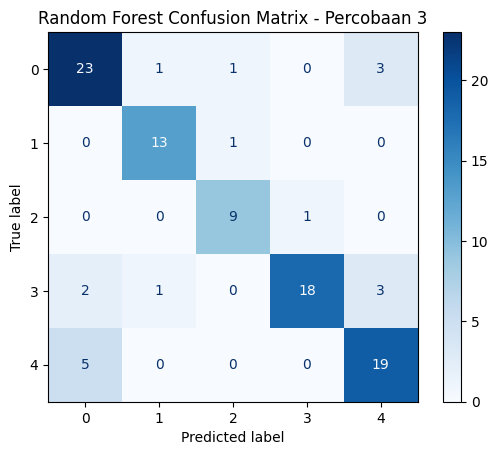

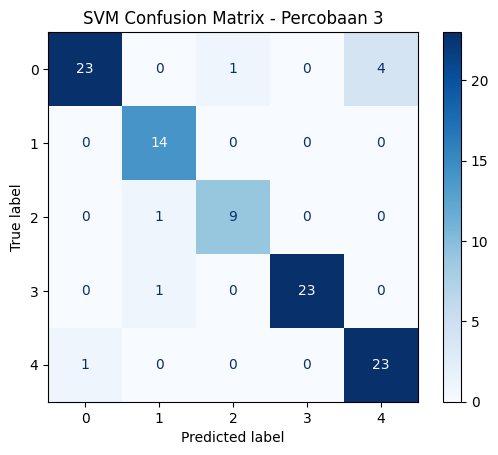

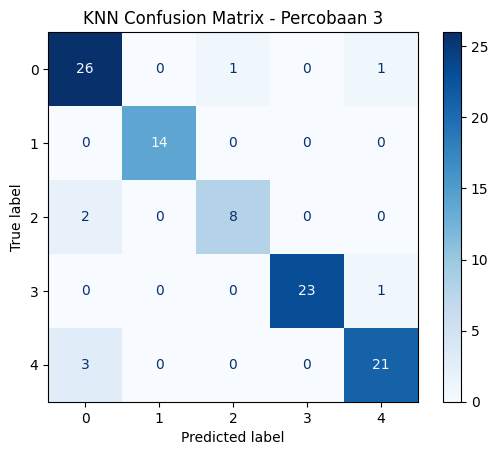

In [17]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 3")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 3")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 3")

## Rekapitulasi dan Penyimpanan Hasil Evaluasi
Blok kode ini berfungsi untuk merekapitulasi dan membandingkan seluruh metrik kinerja dari ketiga model klasifikasi (Random Forest, SVM, dan KNN) ke dalam satu struktur data tabel yang rapi. Program secara otomatis mengekstrak skor akurasi (baik pada himpunan data latih maupun data uji), beserta metrik presisi, *recall*, dan *F1-score* yang dihitung secara berbobot (*weighted*) untuk masing-masing model. 

Seluruh data metrik evaluasi tersebut kemudian dikumpulkan ke dalam sebuah *dictionary* dan dikonversi menjadi objek *DataFrame* menggunakan pustaka Pandas agar mudah dianalisis. Sebagai langkah terakhir, tabel komparasi performa model ini diekspor dan disimpan secara permanen ke dalam *file* berekstensi CSV sebagai dokumentasi final, ditutup dengan pencetakan pesan konfirmasi keberhasilan dan penampilan wujud tabel ringkasannya secara langsung ke layar.

In [18]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./hasil_klasifikasi/hasil_klasifikasi3.csv', index=False)
print("✅ File hasil_klasifikasi3.csv berhasil disimpan!")
df_hasil

✅ File hasil_klasifikasi3.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.9825,0.82,0.827587,0.82,0.820353
1,SVM,0.9600,0.92,0.925278,0.92,0.919723
2,KNN,0.9300,0.92,0.922858,0.92,0.920352
